In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
import warnings
warnings.filterwarnings('ignore')


## 1 - Data Loading & Prep

Load the data, filter out `Open` from `Prospect_Outcome`, drop leaky features, encode categoricals.

In [ ]:
project_root = Path.cwd()
while not (project_root / 'data').exists() and project_root != project_root.parent:
    project_root = project_root.parent

data_path = project_root / 'data' / 'processed' / 'model_ready_dataset.csv'

df = pd.read_csv(data_path)
print(f'Loaded shape: {df.shape}')

# Filter out Open category - only keep Won/Churned
df = df[df['Prospect_Outcome'].isin(['Won', 'Churned'])].copy()

# target: 1 = Churned, 0 = Won
df['target'] = (df['Prospect_Outcome'] == 'Churned').astype(int)
df.drop(columns=['Prospect_Outcome'], inplace=True)

# Drop leaky features identified in EDA
leaky_cols = [
    'Total_Net_Paid', 'price_change_pct', 'price_change_abs',
    'net_paid_vs_last', 'Payment_Method', 'Payment_Timeframe',
    'Days_To_Close_Post_Renewal', 'Total_Renewal_Score_New',
    'Renewal_Year',"em_sentiment_score_mean",
]
df.drop(columns=leaky_cols, inplace=True, errors='ignore')

X = df.drop(columns=['target'])
y = df['target']

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Encode categoricals
cat_cols = X_train_raw.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
if cat_cols:
    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    train_enc_df = pd.DataFrame(ord_enc.fit_transform(X_train_raw[cat_cols]), columns=cat_cols, index=X_train_raw.index)
    test_enc_df  = pd.DataFrame(ord_enc.transform(X_test[cat_cols]), columns=cat_cols, index=X_test.index)
    X_train_raw = X_train_raw.drop(columns=cat_cols).join(train_enc_df)
    X_test      = X_test.drop(columns=cat_cols).join(test_enc_df)

X_train_raw = X_train_raw.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test      = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f'Class distribution in train: {dict(y_train_raw.value_counts())}')
print(f'Train size: {X_train_raw.shape[0]}, Test size: {X_test.shape[0]}, Features: {X_train_raw.shape[1]}')


Loaded shape: (122082, 61)
Class distribution in train: {0: np.int64(80981), 1: np.int64(10134)}
Train size: 91115, Test size: 22779, Features: 51


## 2 - SMOTE Oversampling

The dataset is imbalanced (many more Won than Churned). We apply SMOTE to oversample the minority class on the training set only. We keep the original training set too, so we can compare performance with vs without SMOTE.

In [3]:
# Apply SMOTE to balance class distribution
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_raw, y_train_raw)
print(f'After SMOTE -> Train: {X_train_smote.shape[0]} rows, Churn rate: {y_train_smote.mean():.2%}')


After SMOTE -> Train: 161962 rows, Churn rate: 50.00%


## 3 - Hyperparameter Tuning (Grid Search)

We run `GridSearchCV` on both datasets (with and without SMOTE) to find the best `max_depth`, `criterion`, and `min_samples_split` for the Decision Tree.

In [4]:
# Hyperparameter tuning with GridSearchCV - trying a few params
print('Running grid search on Decision Tree...')

tree = DecisionTreeClassifier(random_state=42)

my_params = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 10],
    'criterion': ['gini', 'entropy']
}

grid_smote = GridSearchCV(tree, my_params, cv=3, scoring='f1')
grid_smote.fit(X_train_smote, y_train_smote)

grid_nosmote = GridSearchCV(DecisionTreeClassifier(random_state=42), my_params, cv=3, scoring='f1')
grid_nosmote.fit(X_train_raw, y_train_raw)

print('Best params (with SMOTE)   :', grid_smote.best_params_)
print('Best params (without SMOTE):', grid_nosmote.best_params_)


Running grid search on Decision Tree...
Best params (with SMOTE)   : {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 10}
Best params (without SMOTE): {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10}


## 4 - Train Final Models & Evaluate

Train two Decision Tree models (with and without SMOTE) using the best hyperparameters found, then compare their metrics on the held-out test set.

In [5]:
# Train final models using best hyperparameters

# -- With SMOTE --
dt_smote = DecisionTreeClassifier(**grid_smote.best_params_, random_state=42)
dt_smote.fit(X_train_smote, y_train_smote)
preds_smote = dt_smote.predict(X_test)

# -- Without SMOTE --
dt_nosmote = DecisionTreeClassifier(**grid_nosmote.best_params_, random_state=42)
dt_nosmote.fit(X_train_raw, y_train_raw)
preds_nosmote = dt_nosmote.predict(X_test)

from sklearn.metrics import classification_report

print('===== WITH SMOTE =====')
print(f'ACC : {accuracy_score(y_test, preds_smote):.4f}')
print(f'Prec: {precision_score(y_test, preds_smote):.4f}')
print(f'Rec : {recall_score(y_test, preds_smote):.4f}')
print(f'F1  : {f1_score(y_test, preds_smote):.4f}')
print(classification_report(y_test, preds_smote, target_names=['Won', 'Churn']))

print('===== WITHOUT SMOTE =====')
print(f'ACC : {accuracy_score(y_test, preds_nosmote):.4f}')
print(f'Prec: {precision_score(y_test, preds_nosmote):.4f}')
print(f'Rec : {recall_score(y_test, preds_nosmote):.4f}')
print(f'F1  : {f1_score(y_test, preds_nosmote):.4f}')
print(classification_report(y_test, preds_nosmote, target_names=['Won', 'Churn']))


===== WITH SMOTE =====
ACC : 0.9432
Prec: 0.7106
Rec : 0.8256
F1  : 0.7638
              precision    recall  f1-score   support

         Won       0.98      0.96      0.97     20245
       Churn       0.71      0.83      0.76      2534

    accuracy                           0.94     22779
   macro avg       0.84      0.89      0.87     22779
weighted avg       0.95      0.94      0.95     22779

===== WITHOUT SMOTE =====
ACC : 0.9521
Prec: 0.8620
Rec : 0.6780
F1  : 0.7590
              precision    recall  f1-score   support

         Won       0.96      0.99      0.97     20245
       Churn       0.86      0.68      0.76      2534

    accuracy                           0.95     22779
   macro avg       0.91      0.83      0.87     22779
weighted avg       0.95      0.95      0.95     22779



## 5 - Confusion Matrix Comparison

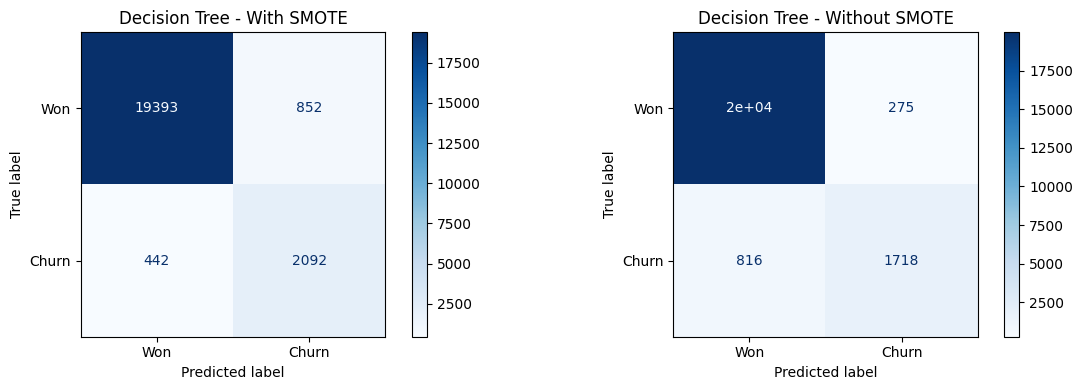

Summary comparison:
  With SMOTE    -> Rec: 0.826  Prec: 0.711  F1: 0.764
  Without SMOTE -> Rec: 0.678  Prec: 0.862  F1: 0.759


In [6]:
# Confusion matrix comparison
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [preds_smote, preds_nosmote],
    ['Decision Tree - With SMOTE', 'Decision Tree - Without SMOTE']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Won', 'Churn'])
    disp.plot(cmap='Blues', ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

print('Summary comparison:')
print(f'  With SMOTE    -> Rec: {recall_score(y_test, preds_smote):.3f}  Prec: {precision_score(y_test, preds_smote):.3f}  F1: {f1_score(y_test, preds_smote):.3f}')
print(f'  Without SMOTE -> Rec: {recall_score(y_test, preds_nosmote):.3f}  Prec: {precision_score(y_test, preds_nosmote):.3f}  F1: {f1_score(y_test, preds_nosmote):.3f}')
